This jupyter notebook reads in the output from grasshopper, detects coincidences between the two planes, and performs the kinematic analysis.  However it performs an additional "trick":  it "confuses" the up and down, thus determining the contributions from the albedo neutrons coming from below.

In [1]:
# Implement the requested processing steps (a–d) and save TSV outputs.
import pandas as pd
from pathlib import Path
import numpy as np

#path = Path("9U_upside.dat")
path = Path("9U_upside.dat")
df = pd.read_csv(path, sep=r"\s+", engine="python")

# Column names (from inspection)
COL_EVENT = "EventID"
COL_PARTICLE = "ParticleName"
COL_DET = "detector#"
COL_E = "E_deposited(MeV)"
COL_X = "x_incident"
COL_Y = "y_incident"
COL_Z = "z_incident"
COL_T = "Time"

out_a = Path("filtered_outputs/a_proton_filtered_upside.tsv")
out_b = Path("filtered_outputs/b_grouped_by_event_detector_upside.tsv")
out_c = Path("filtered_outputs/c_minmax_detector_pairs_upside.tsv")
out_d = Path("filtered_outputs/d_final_metrics_upside.tsv")

# (a) Filter to ParticleName == 'proton'
a = df[df[COL_PARTICLE].str.lower() == "proton"].copy()
a.to_csv(out_a, sep="\t", index=False)

# (b) Group by EventID and detector#, sum E_deposited, average x,y,z,Time
agg_spec = {
    COL_E: "sum",
    COL_X: "mean",
    COL_Y: "mean",
    COL_Z: "mean",
    COL_T: "mean",
}
b = (
    a
    .groupby([COL_EVENT, COL_DET], as_index=False)
    .agg(agg_spec)
    .rename(
        columns={
            COL_E: "E_deposited_sum(MeV)",
            COL_X: "x_incident_mean",
            COL_Y: "y_incident_mean",
            COL_Z: "z_incident_mean",
            COL_T: "Time_mean",
        }
    )
    .sort_values([COL_EVENT, COL_DET])
)
b.to_csv(out_b, sep="\t", index=False)

'''
# (c) For each EventID, pick the two rows with the largest difference in detector# (min & max detector#)
# Keep only EventIDs that have at least 2 distinct detectors
counts = b.groupby(COL_EVENT)[COL_DET].nunique()
eligible_events = counts[counts >= 2].index

b_eligible = b[b[COL_EVENT].isin(eligible_events)].copy()
# Compute min and max detector per event
min_rows = b_eligible.loc[b_eligible.groupby(COL_EVENT)[COL_DET].idxmin()].copy()
max_rows = b_eligible.loc[b_eligible.groupby(COL_EVENT)[COL_DET].idxmax()].copy()
'''
# drop in replacement =========
# (c) For each EventID, pick the min detector and then the next detector in that event
# Keep only EventIDs that have at least 2 distinct detectors
counts = b.groupby(COL_EVENT)[COL_DET].nunique()
eligible_events = counts[counts >= 2].index

# Sort by detector# within each event and take the first two rows (min, next)
b_eligible = (
    b[b[COL_EVENT].isin(eligible_events)]
    .sort_values([COL_EVENT, COL_DET])
    .copy()
)
b_eligible["ord"] = b_eligible.groupby(COL_EVENT).cumcount()

# min detector per event
min_rows = b_eligible[b_eligible["ord"] == 0].copy()

# next detector per event (second smallest)
max_rows = b_eligible[b_eligible["ord"] == 1].copy()

#=======

# Make columns explicit for min/max
suffix_map = {
    "E_deposited_sum(MeV)": "E_low(MeV)",
    "x_incident_mean": "x_low",
    "y_incident_mean": "y_low",
    "z_incident_mean": "z_low",
    "Time_mean": "Time_low",
    COL_DET: "det_low",
}
min_rows = min_rows.rename(columns=suffix_map)

suffix_map_hi = {
    "E_deposited_sum(MeV)": "E_high(MeV)",
    "x_incident_mean": "x_high",
    "y_incident_mean": "y_high",
    "z_incident_mean": "z_high",
    "Time_mean": "Time_high",
    COL_DET: "det_high",
}
max_rows = max_rows.rename(columns=suffix_map_hi)

# Merge to get one row per EventID with low/high entries
c = pd.merge(
    min_rows[[COL_EVENT, "det_low", "E_low(MeV)", "x_low", "y_low", "z_low", "Time_low"]],
    max_rows[[COL_EVENT, "det_high", "E_high(MeV)", "x_high", "y_high", "z_high", "Time_high"]],
    on=COL_EVENT,
    how="inner"
)

# Ensure det_low < det_high; if not, swap
swap_mask = c["det_low"] > c["det_high"]
for lo, hi in [("det_low", "det_high"),
               ("E_low(MeV)", "E_high(MeV)"),
               ("x_low", "x_high"),
               ("y_low", "y_high"),
               ("z_low", "z_high"),
               ("Time_low", "Time_high")]:
    tmp = c.loc[swap_mask, lo].copy()
    c.loc[swap_mask, lo] = c.loc[swap_mask, hi].values
    c.loc[swap_mask, hi] = tmp.values

c.to_csv(out_c, sep="\t", index=False)

# (d) Record requested fields:
# - E_deposited of entry with lowest detector#  -> E_low(MeV)
# - difference in Time between the two entries   -> Time_high - Time_low
# - differences in x_incident, y_incident, z_incident -> high - low
d = c.copy()
d["dTime"] = d["Time_high"] - d["Time_low"]
d["dx_incident"] = d["x_high"] - d["x_low"]
d["dy_incident"] = d["y_high"] - d["y_low"]
d["dz_incident"] = d["z_high"] - d["z_low"]

d_final = d[[COL_EVENT, "det_low", "det_high", "E_low(MeV)", "E_high(MeV)", "dTime", "dx_incident", "dy_incident", "dz_incident"]]\
    .sort_values(COL_EVENT)

# Save final TSV
d_final.to_csv(out_d, sep="\t", index=False)

#import ace_tools as tools; tools.display_dataframe_to_user("Final metrics (step d)", d_final.head(50))

str(out_a), str(out_b), str(out_c), str(out_d), d_final.shape


('filtered_outputs/a_proton_filtered_upside.tsv',
 'filtered_outputs/b_grouped_by_event_detector_upside.tsv',
 'filtered_outputs/c_minmax_detector_pairs_upside.tsv',
 'filtered_outputs/d_final_metrics_upside.tsv',
 (4288, 9))

In [2]:
# Compute r, angle to z, velocity, and neutron kinetic energy from d_final_metrics.tsv
import pandas as pd
import numpy as np
from pathlib import Path

in_path = Path("filtered_outputs/d_final_metrics_upside.tsv")
out_path = Path("filtered_outputs/d1_neutron_kinematics_upside.tsv")

# Load
df = pd.read_csv(in_path, sep="\t")

# Ensure numeric types
for col in ["dx_incident", "dy_incident", "dz_incident", "dTime"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# (a) r = sqrt(dx^2 + dy^2 + dz^2)  [units: mm]
dx = df["dx_incident"]+np.random.normal(loc=0.0, scale=10, size=len(df)) #smear it by 1cm
dy = df["dy_incident"]+np.random.normal(loc=0.0, scale=10, size=len(df)) #smear it by 1cm
dz = df["dz_incident"]+np.random.normal(loc=0.0, scale=10, size=len(df)) #smear it by 1cm
df["r_mm"] = np.sqrt(dx**2 + dy**2 + dz**2)

# (b) angle to z-axis = arctan( sqrt(dx^2 + dy^2) / dz )
# Use arctan2 for numerical stability and correct quadrants:
rho = np.sqrt(dx**2 + dy**2)
df["angle_to_z_rad"] = np.arctan2(rho, dz) #DON'T WORRY ABOUT DIRECTION, arctan2 takes care of that by keeping track of the sign of dz

# (c) velocity assuming dTime [ns], r [mm]
# speed_mm_per_ns = r_mm / |dTime_ns|
dt_ns = pd.to_numeric(df["dTime"], errors="coerce")+np.random.normal(loc=0.0, scale=1.5, size=len(df)) #add a smear of 1.5 ns 
dt_ns_abs = np.abs(dt_ns)
# Avoid divide-by-zero
#df["speed_mm_per_ns"] = np.where(dt_ns_abs > 0, df["r_mm"] / dt_ns_abs, np.nan)
# Convert to m/s: 1 mm/ns = 1e6 m/s
df["speed_m_per_s"] = np.where(dt_ns_abs > 0, df["r_mm"] / dt_ns_abs, np.nan) * 1e6

# (d) neutron kinetic energy (non-relativistic): KE = 1/2 m v^2
m_n = 1.67492749804e-27  # kg
e_charge = 1.602176634e-19  # J per eV
KE_J = 0.5 * m_n * (df["speed_m_per_s"]**2)
df["KE_MeV"] = KE_J / e_charge / 1e6

#now that we have this, let's calculate the 
# a) initial energy of the particle, by summing KE_MeV with E_low(MeV), 
# b) the expected scattering angle, assuming a verticaly incident particle
# c) the bias in scattering angle
# HOWEVER, because we are upside down, we need to "mistake" e_low for e_high
e_high = df["E_low(MeV)"]*(1+np.random.normal(loc=0.0, scale=0.2, size=len(df))) #add energy resolution, 20%
e_low = df["E_high(MeV)"]*(1+np.random.normal(loc=0.0, scale=0.2, size=len(df)))

df["theta_error"] = np.where(d["dTime"] > 0, np.arcsin(np.sqrt(e_low/(df["KE_MeV"]+e_low)))-df["angle_to_z_rad"],
                   np.where(d["dTime"] < 0, np.arcsin(np.sqrt(e_high/(df["KE_MeV"]+e_high)))-df["angle_to_z_rad"], np.nan))

    

# (Optional) sanity check: beta = v/c
c = 299_792_458.0
#df["beta"] = df["speed_m_per_s"] / c

# Save results
df.to_csv(out_path, sep="\t", index=False)

# Show a preview
#import ace_tools as tools; tools.display_dataframe_to_user("Neutron kinematics derived from d_final", df.head(50))

str(out_path), df.shape


('filtered_outputs/d1_neutron_kinematics_upside.tsv', (4288, 14))

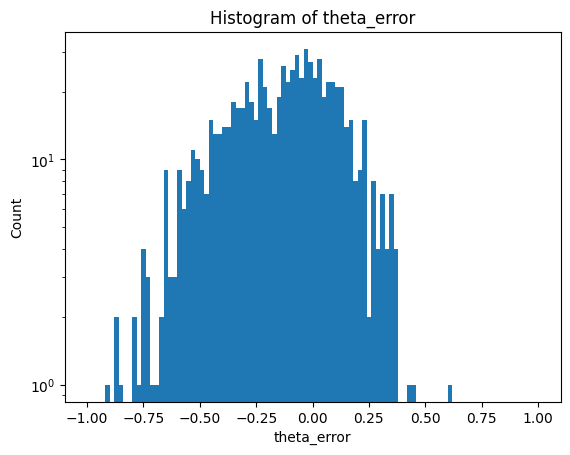

Total, counts>0.95, counts/total >0.95:	 806 0 0.0


In [5]:
#now let's find out which fraction of the reconstructed angles fall within cos(theta_err)>0.95
import matplotlib.pyplot as plt

mask = (df["E_low(MeV)"] > 0.2) & (df["E_high(MeV)"] > 0.2) #minimum energy for detection set to 0.2 MeV
plt.hist(np.cos(df.loc[mask,"theta_error"]).dropna(), bins=100,range=(-1,1))
plt.xlabel("theta_error")
plt.ylabel("Count")
plt.yscale("log")
plt.title("Histogram of theta_error")
plt.show()

counts, edges = np.histogram(np.cos(df.loc[mask,"theta_error"]).dropna(), bins=100,range=(-1,1))
total = counts.sum()
bin_mask = (edges[:-1] >= 0.95) & (edges[1:] <= 1) #keep only events within 0.05 of 1
count_bins_in_range = counts[bin_mask].sum()
print("Total, counts>0.95, counts/total >0.95:\t",total,count_bins_in_range,count_bins_in_range/total)
np.savez("theta_error_histogram_upside.npz", counts=counts, edges=edges)

In [4]:
#plt.hist(1+np.random.normal(loc=0.0, scale=0.2, size=len(df)))
np.arctan2(170, -202.82999999999998)

np.float64(2.4440241688858304)